<a href="https://colab.research.google.com/github/noushks/2026/blob/Regression_Imposter_syndrome/Regression_Analysis_Imposter_Syndrome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Imposter Syndrome Regression Analysis:

Predicts imposter syndrome score (0-100) from psychological and
workplace-related features using multiple regression approaches.


In [26]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score




In [14]:
from google.colab import files
uploaded = files.upload()

Saving imposter_syndrome_data.xlsx to imposter_syndrome_data.xlsx


In [16]:
# ── 1. Load Dataset ───────────────────────────────────────────────────────────
FEATURE_NAMES = [
    "years_experience",      # more experience → lower IS
    "num_achievements",      # more achievements → lower IS
    "peer_comparison_freq",  # how often you compare yourself to peers (1-10)
    "perfectionism_score",   # self-rated perfectionism (1-10)
    "social_support",        # support network quality (1-10)
    "failure_attribution",   # tendency to blame self for failures (1-10)
    "new_role_months",       # months since last promotion/new role
    "field_switch",          # 1 if recently switched fields, 0 otherwise
]

df = pd.read_excel("imposter_syndrome_data.xlsx")
X = df[FEATURE_NAMES]
y = df["imposter_syndrome_score"]

print(f"Loaded {len(df)} rows from imposter_syndrome_data.xlsx")

Loaded 30 rows from imposter_syndrome_data.xlsx


=== Dataset Summary ===
       years_experience  num_achievements  peer_comparison_freq  \
count             30.00             30.00                 30.00   
mean               7.31             10.73                  5.81   
std                5.61              7.95                  2.70   
min                0.30              0.00                  1.50   
25%                2.42              3.25                  3.58   
50%                6.10              9.50                  5.90   
75%               11.00             16.75                  8.25   
max               18.50             25.00                  9.70   

       perfectionism_score  social_support  failure_attribution  \
count                30.00           30.00                30.00   
mean                  6.33            5.49                 5.78   
std                   2.31            2.38                 2.66   
min                   2.80            2.00                 1.80   
25%                   4.12           

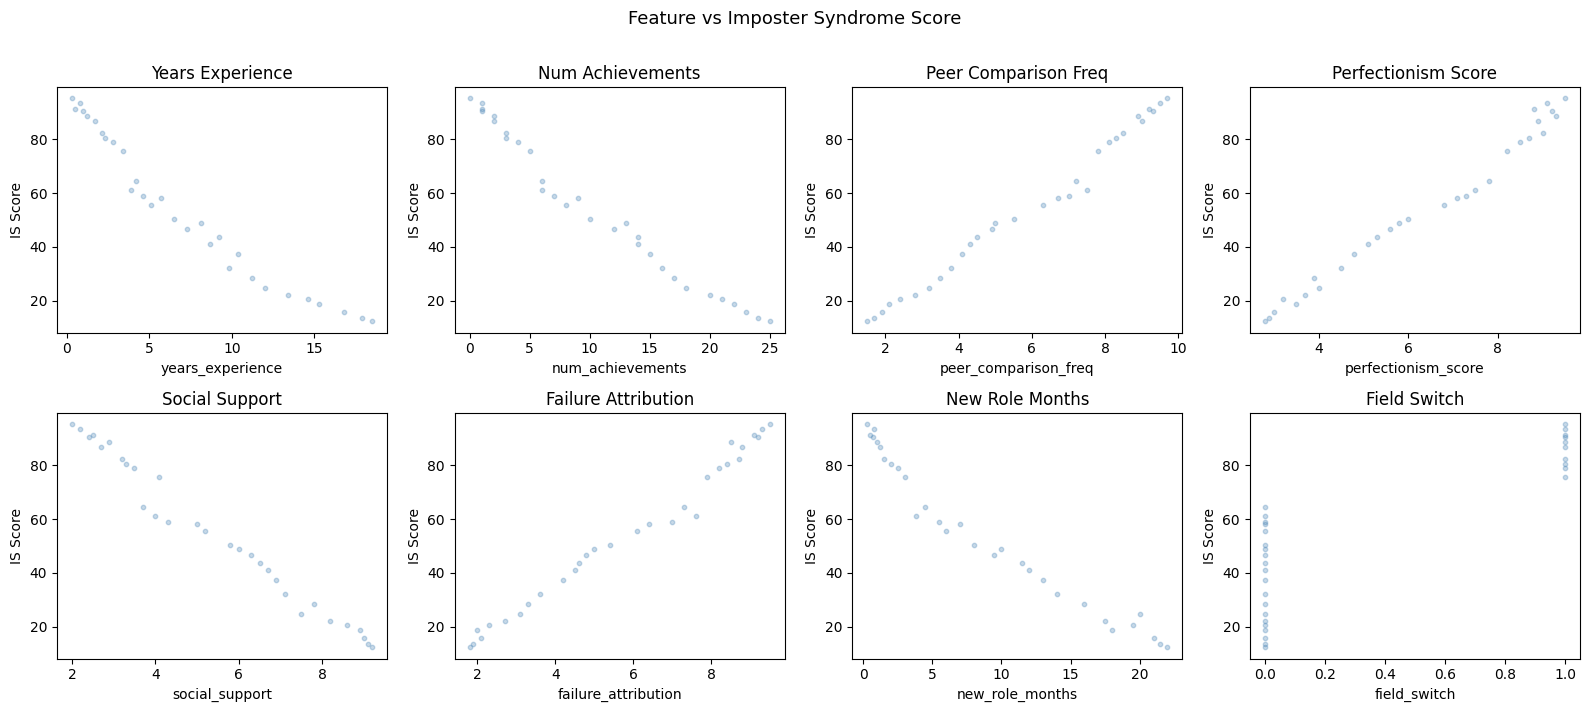

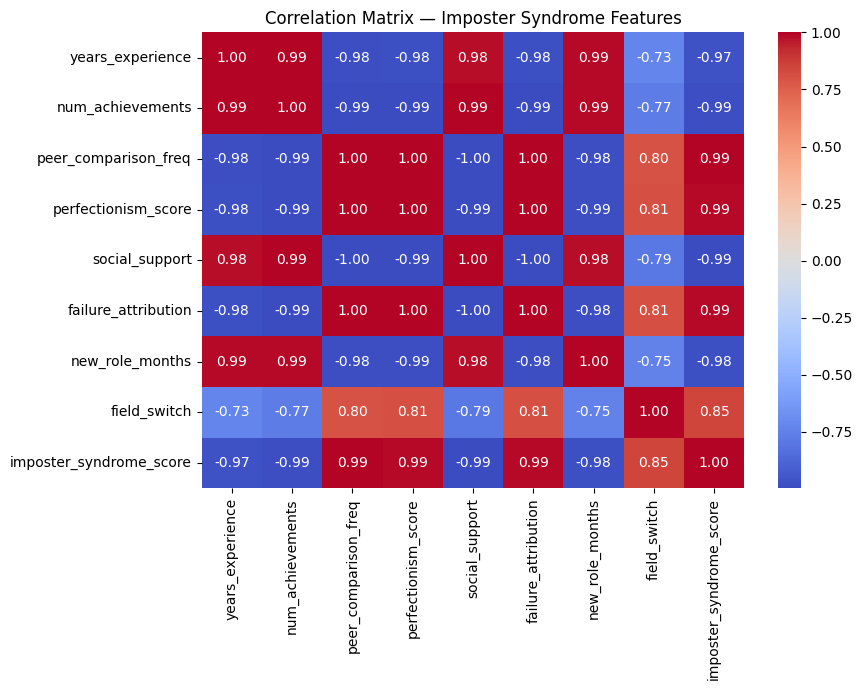

In [18]:
# ── 2. Exploratory Data Analysis ─────────────────────────────────────────────
print("=== Dataset Summary ===")
print(X.describe().round(2))
print(f"\nTarget mean: {y.mean():.2f}  std: {y.std():.2f}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

# Scatter plots
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURE_NAMES):
    axes[i].scatter(X[col], y, alpha=0.3, s=10, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("IS Score")
    axes[i].set_title(col.replace("_", " ").title())

plt.suptitle("Feature vs Imposter Syndrome Score", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_data = pd.concat([X, y], axis=1)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Imposter Syndrome Features")
plt.tight_layout()
plt.show()


In [20]:
# ── 3. Train / Test Split & Scaling ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")




Training set size: 24


In [21]:
# ── 4. Model Training ─────────────────────────────────────────────────────────
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)":   Ridge(alpha=1.0),
    "Lasso (alpha=0.5)": Lasso(alpha=0.5),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred   = model.predict(X_test_sc)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    r2       = r2_score(y_test, y_pred)
    cv_r2    = cross_val_score(model, X_train_sc, y_train, cv=5, scoring="r2").mean()
    results[name] = {"RMSE": rmse, "R²": r2, "CV R² (mean)": cv_r2}
    print(f"\n{name}")
    print(f"  RMSE         : {rmse:.3f}")
    print(f"  R²           : {r2:.4f}")
    print(f"  CV R² (mean) : {cv_r2:.4f}")


Linear Regression
  RMSE         : 3.830
  R²           : 0.9475
  CV R² (mean) : 0.9838

Ridge (alpha=1)
  RMSE         : 1.769
  R²           : 0.9888
  CV R² (mean) : 0.9919

Lasso (alpha=0.5)
  RMSE         : 2.496
  R²           : 0.9777
  CV R² (mean) : 0.9894



=== Coefficients (standardised) ===
                      Linear Regression  Ridge (alpha=1)  Lasso (alpha=0.5)
years_experience                  0.996           -3.028             -0.973
num_achievements                 -0.023           -3.153             -0.000
peer_comparison_freq             -2.104            3.909              0.000
perfectionism_score              -7.059            3.346              0.000
social_support                  -36.418           -4.767            -16.902
failure_attribution             -19.456            3.246              0.000
new_role_months                 -15.730           -3.338             -6.397
field_switch                      7.483            4.635              4.851


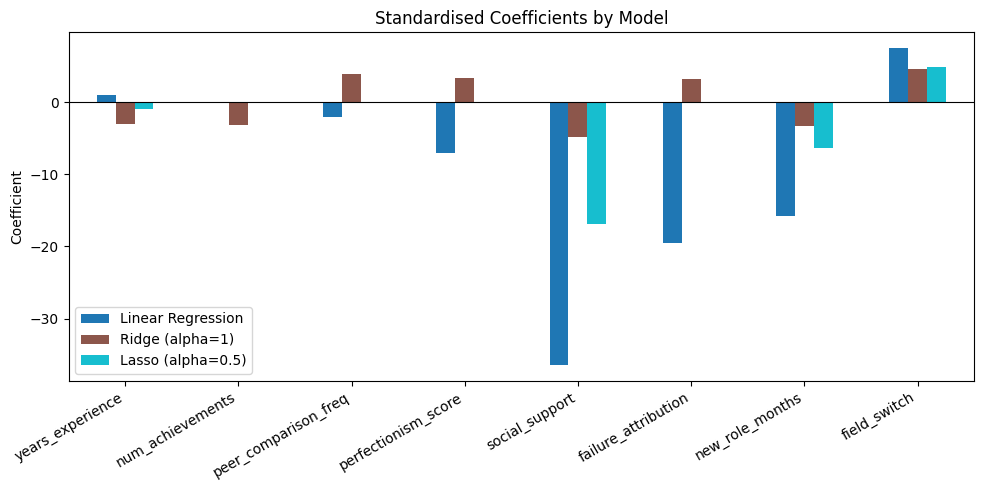

In [23]:
# ── 5. Coefficient Comparison ─────────────────────────────────────────────────
coef_df = pd.DataFrame(
    {name: model.coef_ for name, model in models.items()},
    index=FEATURE_NAMES,
)

print("\n=== Coefficients (standardised) ===")
print(coef_df.round(3))

coef_df.plot(kind="bar", figsize=(10, 5), colormap="tab10")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Standardised Coefficients by Model")
plt.ylabel("Coefficient")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

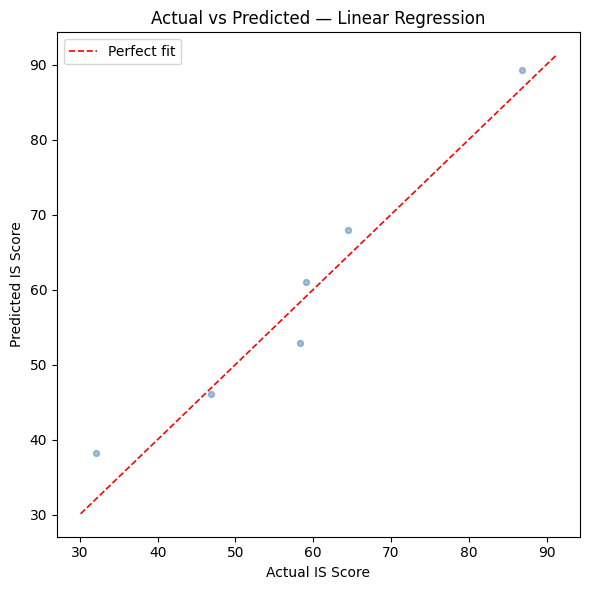

In [24]:
# ── 6. Actual vs Predicted ────────────────────────────────────────────────────
best_model = models["Linear Regression"]
y_pred_best = best_model.predict(X_test_sc)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, s=18, color="steelblue")

lims = [min(y_test.min(), y_pred_best.min()) - 2,
        max(y_test.max(), y_pred_best.max()) + 2]

plt.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")

plt.xlabel("Actual IS Score")
plt.ylabel("Predicted IS Score")
plt.title("Actual vs Predicted — Linear Regression")
plt.legend()
plt.tight_layout()

plt.show()


In [25]:
# ── 7. Results Summary ────────────────────────────────────────────────────────
print("\n=== Model Comparison ===")
results_df = pd.DataFrame(results).T
print(results_df.round(4))


=== Model Comparison ===
                     RMSE      R²  CV R² (mean)
Linear Regression  3.8296  0.9475        0.9838
Ridge (alpha=1)    1.7689  0.9888        0.9919
Lasso (alpha=0.5)  2.4961  0.9777        0.9894
